In [52]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.transforms.functional import normalize

In [164]:
im_path = "/data/datasets/nii/BTCV/imagesTs/img0003.nii.gz"
gt_path = "/data/datasets/nii/BTCV/labelsTs/img0003.nii.gz"
im = nib.load(im_path).get_fdata(dtype=np.float32)
gt = nib.load(gt_path).get_fdata(dtype=np.float32)

In [165]:
im.shape, gt.shape

((512, 512, 198), (512, 512, 198))

In [166]:
im = torch.Tensor(im)
im = im.permute(2,0,1).unsqueeze(1).repeat(1,3,1,1)
# im = normalize(im, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
im = im.permute(0, 2, 3, 1)
im = (im - im.min()) / (im.max() - im.min())

gt = np.where(gt == 3, 1, 0)

In [167]:
im.shape

torch.Size([198, 512, 512, 3])

In [168]:
np.argwhere(gt.sum(axis=(0, 1))).squeeze()

array([ 98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
       111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123,
       124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136,
       137, 138, 139])

In [205]:
i, j, k = 113, 118, 120

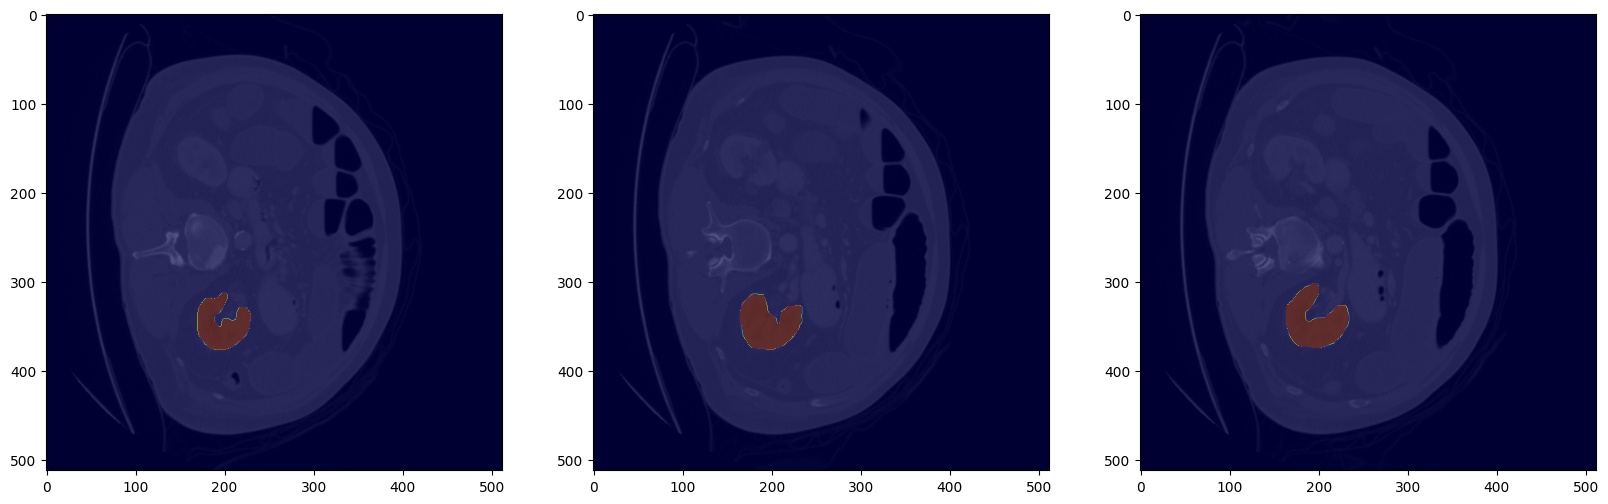

In [209]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(20,10))
ax1.imshow(im[i], cmap="grey")
ax1.imshow(gt[:, :, i], alpha=0.4, cmap="jet")
ax2.imshow(im[j], cmap="grey")
ax2.imshow(gt[:, :, j], alpha=0.4, cmap="jet")
ax3.imshow(im[k], cmap="grey")
ax3.imshow(gt[:, :, k], alpha=0.4, cmap="jet")